# Lab:  Source Localization for EEG

EEG or [Electroencephalography](https://en.wikipedia.org/wiki/Electroencephalography) is a powerful tool for neuroscientists in understanding brain activity.  In EEG, a patient wears a headset with electrodes that measures voltages at a number of points on the scalp.  These voltages arise from ionic currents within the brain.  A common *inverse problem* is to estimate the which parts of the brain caused the measured response.  Source localization is useful in understanding which parts of the brain are involved in certain tasks.  A key challenge in this inverse problem is that **the number of unknowns (possible locations in the brain) is much larger than the number of measurements**.  In this lab, we will use LASSO regression on a real EEG dataset to overcome this problem and determine the brain region that is active under an auditory stimulus.

In addition to the concepts in the [prostate LASSO demo](./demo_prostate.ipynb) you will learn to:
* Represent responses of multi-channel time-series data, such as EEG, using linear models
* Perform LASSO and Ridge regression
* Select the regularization level via cross-validation
* Visually compare the sparsity between the solutions

We first download standard packages.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

## Load the Data

The data in this lab is taken from one of the sample datasets in the [MNE website](https://martinos.org/mne/stable/index.html). The sample data is a recording from one subject who experienced some auditory stimulus on the left ear.    

The raw data is very large (`1.5G`) and also requires that you install the `mne` python package. To make this lab easier, I have extracted and processed a small section of the data. The following command will download a `pickle` file `eeg_dat.p` to your local machine.  If you do want to create the data yourself, the program to create the data is in this directory in the github repository.

In [20]:
fn_src ='https://drive.google.com/uc?export=download&id=1RzQpKONOcXSMxH2ZzOI4iVMiTgD6ttSl'
fn_dst ='eeg_dat.p'

import os
from six.moves import urllib

if os.path.isfile(fn_dst):
    print('File %s is already downloaded' % fn_dst)
else:        
    print('Fetching file %s [53MB].  This may take a minute..' % fn_dst)
    urllib.request.urlretrieve(fn_src, fn_dst)
    print('File %s downloaded' % fn_dst)

File eeg_dat.p is already downloaded


Now run the following command which will get the data from the `pickle` file.

In [21]:
import pickle
fn = 'eeg_dat.p'
with open(fn, 'rb') as fp:
    [X,Y] = pickle.load(fp)

To understand the data, there are three key variables:
* `nt`    = number of time steps that we measure data
* `nchan` = number of channels (i.e. electrodes) measured in each time step
* `ncur`  = number of currents in the brain that we want to estimate.  

Each current comes from one brain region (called a *voxel*) in either the `x`, `y` or `z` direction.  So,

    nvoxels = ncur / 3
    
The components of the `X` and `Y` matrices are:
*  `Y[i,k]` = electric field measurement on channel `i` at time `k`
*  `X[i,j]` = sensitivity of channel `i` to current `j`.

Using `X.shape` and `Y.shape` compute and print `nt`, `nchan`, `ncur` and `nvoxels`.

In [22]:
X.shape, Y.shape

((305, 22494), (305, 85))

In [23]:
# TODO
# nt = ...
# ncur = ...
# nchan = ...
# nvoxels
ncur = X.shape[1]
nvoxels = ncur/3
nchan, nt = Y.shape

print("number of currents to estimate (ncur): %d" % ncur)
print("number of voxels (nvoxels): %d" % nvoxels)
print("number of channels (nchan): %d" % nchan)
print("number of time steps (nt): %d" % nt)

number of currents to estimate (ncur): 22494
number of voxels (nvoxels): 7498
number of channels (nchan): 305
number of time steps (nt): 85


## Ridge Regression

Our goal is to estimate the currents in the brain from the measurements `Y`.  One simple linear model is:

    Y[i,k]  = \sum_j X[i,j]*W[j,k]+ b[k]

where `W[j,k]` is the value of current `j` at time `k` and `b[k]` is a bias.  We can solve for the current matrix `W` via linear regression.  

Howeever, there is a problem:
*  There are `nt x ncur` unknowns in `W`
*  There are only `nt x nchan` measurements in `Y`.

In this problem, we have:

    number of measurements  << number of unknowns
    
We need to use regularization in these circumstances.  We first try Ridge regression.

First split the data into training and test.  Use the `train_test_split` function with `test_size=0.33`.

In [24]:
# TODO
# Xtr,Xts,Ytr,Yts = train_test_split(...) 
Xtr, Xts, Ytr, Yts = train_test_split(X, Y, test_size=0.333)

Use the `Ridge` regression object in `sklearn` to fit the model on the training data.  Use a regularization, `alpha=1`.

In [25]:
# TODO
# regr = Ridge(...)
regr = Ridge(alpha=1)
regr.fit(Xtr, Ytr)

Ridge(alpha=1)

Preict the values `Y` on both the training and test data.  Use the `r2_score` method to measure the `R^2` value on both the training and test.  You will see that `R^2` value is large for the training data, it is very low for the test data.  This suggest that even with regularization, the model is over-fitting the data.

**NOTE**
- ridge(α=1) learns training well but does poorly on testing

In [26]:
# TODO
# rsq_tr = ...
# rsq_ts = ...
Ytr_hat = regr.predict(Xtr)
Yts_hat = regr.predict(Xts)

trrsq = r2_score(Ytr,Ytr_hat)
tsrsq = r2_score(Yts,Yts_hat)

print("training R^2 = %f" % trrsq)
print("testing R^2 = %f" % tsrsq)

training R^2 = 0.584770
testing R^2 = 0.180358


Next, try to see if we can get a better `R^2` score using different values of `alpha`.  Use cross-validation to measure the test `R^2` for 20 `alpha` values logarithmically spaced from `10^{-2}` to `10^{2}` (use `np.logspace()`).  You can use regular cross-validation.  You do not need to do `K`-fold.

In [27]:
# TODO
# using training set (xtr and ytr) to train model 
# and evaluating using testing set (xts and yts)
# for each alpha value train and evaluate and measure R^2

# Alpha values:
alphas = np.logspace(-2, 2, 20)
nalpha = len(alphas)

# 1-fold cross-validation
rsq_ridge_alphas = np.zeros(nalpha)
for i_a, a in enumerate(alphas):
    reg = Ridge(alpha=a)
    reg.fit(Xtr, Ytr)
    Y_hat = reg.predict(Xts)
    rsq_ridge_alphas[i_a] = r2_score(Yts,Y_hat)

print("rsq_ridge_alphas: ", rsq_ridge_alphas)

rsq_ridge_alphas:  [-0.069393   -0.00618711  0.04780941  0.09634911  0.14048906  0.17863696
  0.20696238  0.22069066  0.21662723  0.1956546   0.16305299  0.12615705
  0.09129617  0.06210716  0.03959688  0.02315445  0.01158093  0.00366834
 -0.00160524 -0.00504348]


Plot the test `R^2` vs. `alpha`.  And print the maximum test `R^2`.  You should see that the maximum test `R^2` is still not very high.

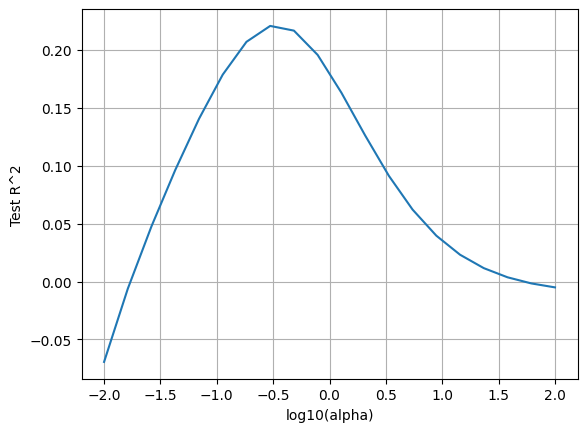

In [28]:
# TODO
plt.plot(np.log10(alphas),rsq_ridge_alphas)
plt.xlabel('log10(alpha)')
plt.ylabel('Test R^2')
plt.grid()

Now, let's take a look at the solution. 

* Find the optimal regularization `alpha` from the cross-validation
* Re-fit the model at the optimal `alpha`
* Get the current matrix `W` from the coefficients in the linear model.  These are stored in `regr.coef_`.  You may need a transpose
* For each current `j` compute `Wrms[j] =  sqrt( sum_k W[j,k]**2 )` which is root mean squared current.

You will see that the vector `Wrms` is not sparse.  This means that the solution that is found with Ridge regression finds currents in all locations.

In [29]:
# TODO
# Find optimal alpha
im = np.argmax(rsq_ridge_alphas)
alpha_normal = alphas[im]
print("alpha optimal for Ridge (normal rule): %f\n"%alpha_normal)

# Fit on entire data
reg = Ridge(alpha=alpha_normal)
reg.fit(Xtr,Ytr)

# Get current matrix
w = reg.coef_.T # T: do a transpose

# compute Wrms
wrms = np.sqrt(np.sum(w**2, axis=1))
print('rms current array (calc using optimal alpha for Ridge):\n ', wrms)

alpha optimal for Ridge (normal rule): 0.297635

rms current array (calc using optimal alpha for Ridge):
  [0.29021779 0.16072888 0.21400251 ... 0.06545517 0.06622987 0.04612355]


## LASSO Regression

We can improve the estimate by imposing sparsity.  Biologically, we know that only a limited number of brain regions should be involved in the reponse to a particular stimuli.  As a result, we would expect that the current matrix `W[j,k]` to be zero for most values `j,k`.  We can impose this constraint using LASSO regularization.

Re-fit the training data using the `Lasso` model with `alpha=1e-3`.  Also set `max_iter=100` and `tol=0.01`.  The LASSO solver is much slower, so this make take a minute.

In [30]:
# TODO
reglas = Lasso(alpha=1e-3, max_iter=100, tol=0.01)
reglas.fit(Xtr,Ytr)

Lasso(alpha=0.001, max_iter=100, tol=0.01)

Now, test the model on the test data and measure the `R^2` value.  You should get a much better fit than with the Ridge regression solution.  

In [31]:
# TODO
Y_hat_las = reglas.predict(Xts)
rsq_las = r2_score(Yts,Y_hat_las)
print("Lasso(alpha=0.001) R^2: %.8f"%rsq_las)

Lasso(alpha=0.001) R^2: 0.14385837


We can now search for the optimal `alpha`.  Use cross-validation to find the `alpha` logarithically space between `alpha=10^{-3}` and `alpha=10^{-4}`.  Each fit takes some time, so use only 5 values of `alpha`. Also for each `alpha` store the current matrix.  This way, you will not have to re-fit the model.

In [32]:
# TODO
# Alpha values:
alphas_l = np.logspace(-4, -3, 5)
nalpha = len(alphas_l)

# 1-fold cross-validation
rsq_lasso = np.zeros(nalpha)
list_of_w = []
for i_a, a in enumerate(alphas_l):
    reg = Lasso(alpha=a, max_iter=100, tol=0.01)
    reg.fit(Xtr, Ytr)
    Y_hat = reg.predict(Xts)
    rsq_lasso[i_a] = r2_score(Yts,Y_hat)
    w_i = reg.coef_.T # compute current matrix w for this alpha
    list_of_w.append(w_i)

print("rsq_lasso: ", rsq_lasso)

rsq_lasso:  [0.3019691  0.32690954 0.31132697 0.25622396 0.14385837]


Plot the `r^2` value vs. `alpha`.  Print the optimal `r^2`.  You should see it is much higher than with the best Ridge Regression case.

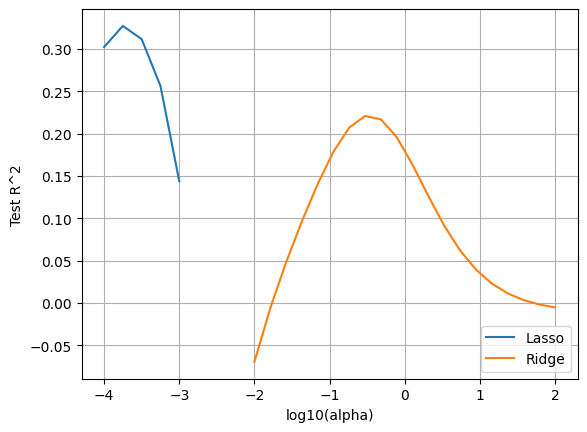

In [33]:
# TODO
plt.plot(np.log10(alphas_l),rsq_lasso)
plt.plot(np.log10(alphas),rsq_ridge_alphas)
plt.xlabel('log10(alpha)')
plt.ylabel('Test R^2')
plt.legend(['Lasso', 'Ridge'], loc='lower right')
plt.grid()

In [34]:
# Find optimal R^2 for lasso
imax = np.argmax(rsq_lasso)
rsq_max_l = rsq_lasso[imax]
print("optimal R^2 of lasso: %f"%rsq_max_l)

# optimal R^2 for ridge
print("optimal R^2 for Ridge (normal rule): %f"%rsq_ridge_alphas[im])

optimal R^2 of lasso: 0.326910
optimal R^2 for Ridge (normal rule): 0.220691


Display the current matrix `W` for the optimal `alpha` as you did in the Ridge Regression case.  You will see that is much sparser.

In [35]:
# TODO
print(list_of_w[imax])

[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.         -0.         -0.         ... -0.         -0.
  -0.        ]
 [-0.25480355 -0.20988317 -0.01600615 ... -0.         -0.
  -0.        ]
 ...
 [ 0.         -0.         -0.         ... -0.         -0.
  -0.        ]
 [-0.          0.          0.         ... -0.          0.
   0.        ]
 [-0.         -0.         -0.         ...  0.          0.
   0.        ]]


In [36]:
wrms_las = np.sqrt(np.sum((list_of_w[imax])**2, axis=1)) 

print(f"Optimal Alpha for LASSO: {alphas_l[imax]}")
print(f"Shape of Wrms (LASSO): {wrms_las.shape}")

tolerance = 1e-15 # Define a small tolerance
non_zero_elements_lasso = np.sum(np.abs(wrms_las) > tolerance)
print(f"Number of non-zero elements in Wrms (LASSO) with tolerance {tolerance}: {non_zero_elements_lasso}")

Optimal Alpha for LASSO: 0.00017782794100389227
Shape of Wrms (LASSO): (22494,)
Number of non-zero elements in Wrms (LASSO) with tolerance 1e-15: 530


## More fun

If you want to more on this lab:
* Install the [MNE python package](https://martinos.org/mne/stable/index.html).  This is an amazing package with many tools for processing EEG data.
* In particular, you can use the above results to visualize where in the brain the currents sources are.
* You can also improve the fitting with more regularization.  For example, we know that the currents will be non-zero in groups:  If the current is non-zero for one time, it is likely to non-zero for all time.  You can use the Group LASSO method.
* You can combine these results to make predictions about what the patient is seeing or hearing or thinking.